In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

In [ ]:
#load dataset

url = "https://raw.githubusercontent.com/plotly/datasets/master/2016-weather-data-seattle.csv"

df = pd.read_csv(url)

print(df.head())
print(df.shape)

       Date  Max_TemperatureC  Mean_TemperatureC  Min_TemperatureC
0  1/1/1948                10                8.0               7.0
1  1/2/1948                 6                4.0               3.0
2  1/3/1948                 7                4.0               2.0
3  1/4/1948                 7                4.0               2.0
4  1/5/1948                 7                3.0               0.0
(24381, 4)


In [ ]:
print(df.head())
print(df.columns)

       Date  Max_TemperatureC  Mean_TemperatureC  Min_TemperatureC
0  1/1/1948                10                8.0               7.0
1  1/2/1948                 6                4.0               3.0
2  1/3/1948                 7                4.0               2.0
3  1/4/1948                 7                4.0               2.0
4  1/5/1948                 7                3.0               0.0
Index(['Date', 'Max_TemperatureC', 'Mean_TemperatureC', 'Min_TemperatureC'], dtype='object')


In [ ]:
# Convert Date to datetime
df["Date"] = pd.to_datetime(df["Date"])

# Sort by date
df = df.sort_values("Date")

# Select Date and Mean Temperature
temperature = df[["Date", "Mean_TemperatureC"]].copy()

print(temperature.head())
print(temperature.shape)

        Date  Mean_TemperatureC
0 1948-01-01                8.0
1 1948-01-02                4.0
2 1948-01-03                4.0
3 1948-01-04                4.0
4 1948-01-05                3.0
(24381, 2)


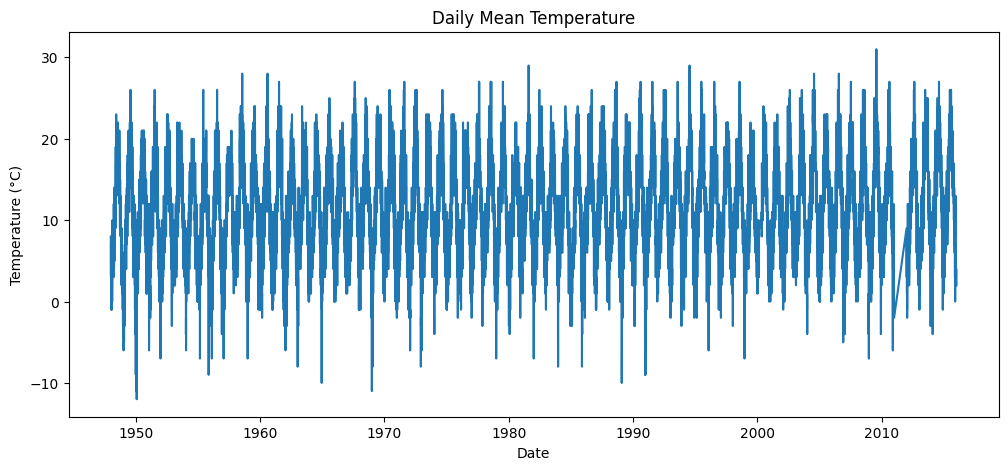

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(
    temperature["Date"],
    temperature["Mean_TemperatureC"]
)

plt.title("Daily Mean Temperature")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")

plt.show()

In [ ]:
#normalise temperature
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0, 1))

scaled_temperature = scaler.fit_transform(
    temperature[["Mean_TemperatureC"]]
)

print(scaled_temperature[:5])

[[0.46511628]
 [0.37209302]
 [0.37209302]
 [0.37209302]
 [0.34883721]]


In [ ]:
print(temperature.isnull().sum())

Date                 0
Mean_TemperatureC    5
dtype: int64


In [ ]:
temperature = temperature.dropna().reset_index(drop=True)

print(temperature.isnull().sum())

Date                 0
Mean_TemperatureC    0
dtype: int64


In [ ]:
scaler = MinMaxScaler(feature_range=(0, 1))

scaled_temperature = scaler.fit_transform(
    temperature[["Mean_TemperatureC"]]
)

In [ ]:
sequence_length = 7

X = []
y = []

for i in range(sequence_length, len(scaled_temperature)):
    X.append(scaled_temperature[i-sequence_length:i, 0])
    y.append(scaled_temperature[i, 0])

X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)

print("Any NaN in X:", np.isnan(X).any())
print("Any NaN in y:", np.isnan(y).any())

X shape: (24369, 7)
y shape: (24369,)
Any NaN in X: False
Any NaN in y: False


In [ ]:
split = int(len(X) * 0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

In [ ]:
X_train = X_train.reshape(
    X_train.shape[0],
    X_train.shape[1],
    1
)

X_test = X_test.reshape(
    X_test.shape[0],
    X_test.shape[1],
    1
)

print(X_train.shape)
print(X_test.shape)

(19495, 7, 1)
(4874, 7, 1)


In [ ]:
#lstm model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model = Sequential()

model.add(
    LSTM(
        50,
        return_sequences=True,
        input_shape=(X_train.shape[1], 1)
    )
)

model.add(Dropout(0.2))

model.add(LSTM(50))

model.add(Dropout(0.2))

model.add(Dense(1))

model.compile(
    optimizer="adam",
    loss="mean_squared_error"
)

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 7, 50)          │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 7, 50)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,651 (119.73 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#training model
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/20
610/610 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 0.0092 - val_loss: 0.0043
Epoch 2/20
610/610 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 0.0055 - val_loss: 0.0035
Epoch 3/20
610/610 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - loss: 0.0047 - val_loss: 0.0033
Epoch 4/20
610/610 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 0.0040 - val_loss: 0.0026
Epoch 5/20
610/610 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - loss: 0.0033 - val_loss: 0.0023
Epoch 6/20
610/610 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - loss: 0.0030 - val_loss: 0.0025
Epoch 7/20
610/610 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - loss: 0.0029 - val_loss: 0.0022
Epoch 8/20
610/610 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - loss: 0.0027 - val_loss: 0.0021
Epoch 9/20
610/610 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - loss: 0.0026 - val_loss: 0.0021
Epoch 10/20
610/610 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - loss: 0.0025 - val_loss: 0.0022
Epoch 11/20
610/610 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - loss: 0.0025 - val_loss: 0.0022
Epoch 12/20
610/610 ━━━━━━━━━━━━━━━━━━━━

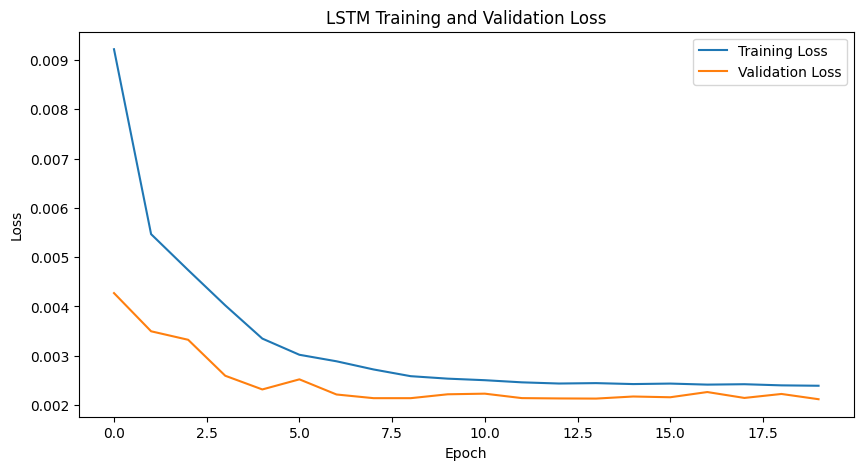

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("LSTM Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [ ]:
predictions = model.predict(X_test)

print("Prediction shape:", predictions.shape)

153/153 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
Prediction shape: (4874, 1)


In [ ]:
predictions = scaler.inverse_transform(predictions)

actual = scaler.inverse_transform(
    y_test.reshape(-1, 1)
)

print("First 5 actual temperatures:")
print(actual[:5])

print("\nFirst 5 predicted temperatures:")
print(predictions[:5])

First 5 actual temperatures:
[[19.]
 [19.]
 [18.]
 [18.]
 [17.]]

First 5 predicted temperatures:
[[16.818495]
 [18.869377]
 [18.59421 ]
 [18.11551 ]
 [18.32776 ]]


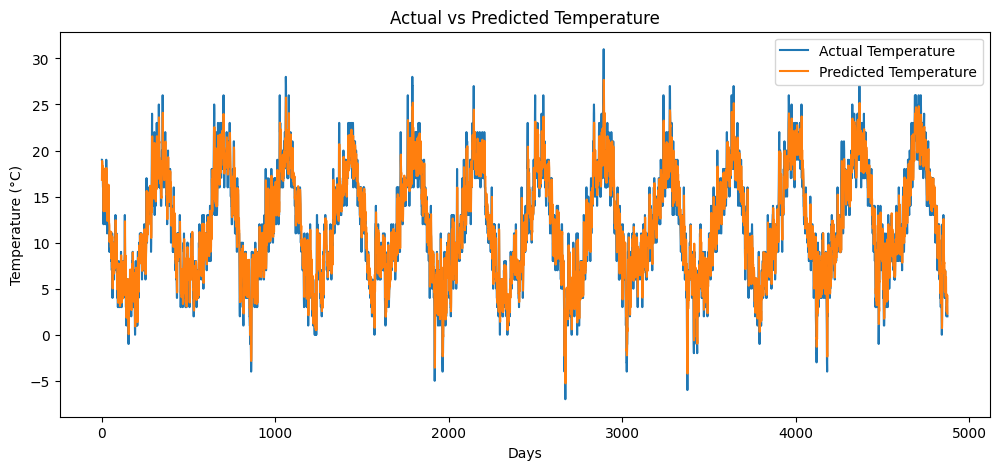

In [ ]:
plt.figure(figsize=(12, 5))

plt.plot(actual, label="Actual Temperature")
plt.plot(predictions, label="Predicted Temperature")

plt.title("Actual vs Predicted Temperature")
plt.xlabel("Days")
plt.ylabel("Temperature (°C)")
plt.legend()

plt.show()

In [ ]:
mae = mean_absolute_error(actual, predictions)

rmse = np.sqrt(
    mean_squared_error(actual, predictions)
)

print("Mean Absolute Error (MAE):", mae)
print("Root Mean Squared Error (RMSE):", rmse)

Mean Absolute Error (MAE): 1.5551287710214179
Root Mean Squared Error (RMSE): 1.978469848490132


In [ ]:
# Get the last 7 temperature values
last_7_days = scaled_temperature[-7:]

# Reshape for LSTM
last_7_days = last_7_days.reshape(1, 7, 1)

# Predict next day
next_day_scaled = model.predict(last_7_days)

# Convert back to Celsius
next_day_temperature = scaler.inverse_transform(
    next_day_scaled
)

print(
    "Predicted temperature for the next day:",
    round(next_day_temperature[0][0], 2),
    "°C"
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Predicted temperature for the next day: 2.46 °C
